In [64]:
from captum.attr import LayerGradCam
from models.TransBTS.TransBTS_downsample8x_skipconnection import TransBTS

In [65]:
_, model = TransBTS(_conv_repr=True, _pe_type="learned")

In [66]:
import os
checkpointDir = r"C:\Users\Rishabh\Documents\TransBTS\checkpoints"
checkpointPath = os.path.join(checkpointDir, 'best_model.pt')
checkpoint = torch.load(checkpointPath, map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])
os.listdir(checkpointDir)

['best_model.pt']

In [67]:
model.eval()

BTS(
  (linear_encoding): Linear(in_features=128, out_features=512, bias=True)
  (position_encoding): LearnedPositionalEncoding()
  (pe_dropout): Dropout(p=0.1, inplace=False)
  (transformer): TransformerModel(
    (net): IntermediateSequential(
      (0): Residual(
        (fn): PreNormDrop(
          (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (fn): SelfAttention(
            (qkv): Linear(in_features=512, out_features=1536, bias=False)
            (attn_drop): Dropout(p=0.1, inplace=False)
            (proj): Linear(in_features=512, out_features=512, bias=True)
            (proj_drop): Dropout(p=0.1, inplace=False)
          )
        )
      )
      (1): Residual(
        (fn): PreNorm(
          (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (fn): FeedForward(
            (net): Sequential(
              (0): Linear(in_features=512, out_features=4096, bias=True)
              (1

In [90]:
model.Unet.EnBlock1

EnBlock(
  (bn1): GroupNorm(8, 16, eps=1e-05, affine=True)
  (relu1): ReLU(inplace=True)
  (conv1): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  (bn2): GroupNorm(8, 16, eps=1e-05, affine=True)
  (relu2): ReLU(inplace=True)
  (conv2): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
)

In [69]:
model.fc1

Linear(in_features=512, out_features=128, bias=True)

In [70]:
model.linear_encoding

Linear(in_features=128, out_features=512, bias=True)

In [71]:
target_layer = model.Unet
# target_layer = model.Unet.EnBlock1.conv2

In [72]:
gradcam = LayerGradCam(model, target_layer)

In [73]:
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import os
import nibabel as nib
import pandas as pd
import torch

class TransBTS_model_dataset(Dataset):
    def __init__(self, BrainMRIFilesPath, CSVPath, transform=None):        
        self.BrainMRIFilesPath = BrainMRIFilesPath
        self.CSVPath = CSVPath
        self.transform = transform
        self.df = pd.read_excel(self.CSVPath , engine='openpyxl')
        
        self.Files = os.listdir(self.BrainMRIFilesPath)

        self.ID_To_Filename = {}
        self.IDs = []
        for file in self.Files:
            strc = file.split('-')
            self.ID_To_Filename[int(strc[0][-3:])] = file
            self.IDs.append(int(strc[0][-3:]))

    def __len__(self):
        return len(self.IDs)

    def __getitem__(self, index):
        ID = self.IDs[index]
        filename = self.ID_To_Filename[ID]
        file_path = os.path.join(self.BrainMRIFilesPath ,filename)
        if self.transform is not None:
            image = transforms(file_path)              # returns torch.Tensor
            array = image.numpy()[0]                    
        
        age = self.df[self.df['IXI_ID'] == ID]['AGE'].values[0]
        return array, age
        

In [74]:
from monai.transforms import LoadImage, Compose, Spacing, Resize, EnsureChannelFirst, ScaleIntensity
import numpy as np
transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),                   # shape: (1, H, W, D)
    ScaleIntensity(),                       # optional: normalize to 0-1
    Spacing(pixdim=(1.0, 1.0, 1.0), mode="bilinear"),  # resample to 1mm spacing
    Resize(spatial_size=(128, 128, 128), mode='trilinear')  # resize to 128³
])

In [75]:
BrainMRIFilesPath = r"C:\Users\Rishabh\Documents\PreprocessedData1mm"
CSVPath = os.path.join(r'C:\Users\Rishabh\Documents\TransBTS', 'IXI.xlsx')
ds = TransBTS_model_dataset(BrainMRIFilesPath, CSVPath , transforms)

In [76]:
ImageVolume, age = ds[0]

In [77]:
ImageVolume = torch.from_numpy(ImageVolume)
ImageVolume= ImageVolume.unsqueeze(0).unsqueeze(0)

In [57]:
ImageVolume.shape

torch.Size([1, 1, 128, 128, 128])

In [79]:
attribution = gradcam.attribute(ImageVolume, target=0)

In [80]:
attr_map = attribution.squeeze().detach().cpu().numpy()

AttributeError: 'tuple' object has no attribute 'squeeze'

In [81]:
attribution.shape

AttributeError: 'tuple' object has no attribute 'shape'

In [44]:
attr_map.shape

(128, 128, 128)

In [82]:
attribution[0].shape

torch.Size([1, 1, 128, 128, 128])

In [91]:
import torch.nn.functional as F

new_attribution = attribution[0]
# new_attribution = [[attr_map]]
# attribution shape: [1, 1, D', H', W']
# Upsample to match input shape: [1, 1, 130, 130, 130] or whatever your input was
upsampled_attr = F.interpolate(
    new_attribution, size=ImageVolume.shape[2:], mode='trilinear', align_corners=False
).squeeze().detach().cpu().numpy()


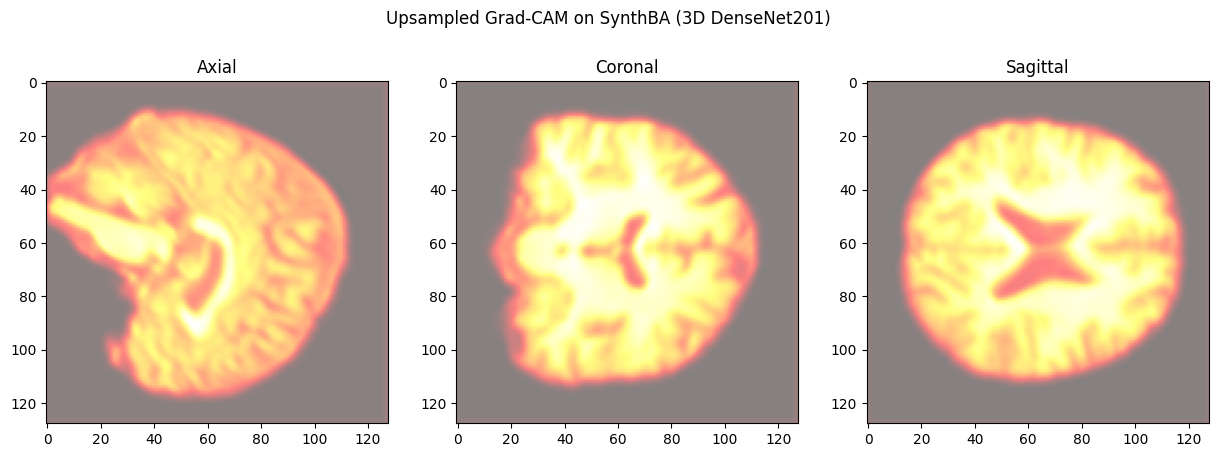

In [92]:
import matplotlib.pyplot as plt

# raw_img: already shape (D, H, W)
attr_map = upsampled_attr

# Get center slices
z, y, x = [s // 2 for s in attr_map.shape]

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(attr_map[z], cmap='hot', alpha=0.5)
plt.title("Axial")

plt.subplot(1,3,2)
plt.imshow(attr_map[:, y, :], cmap='hot', alpha=0.5)
plt.title("Coronal")

plt.subplot(1,3,3)
plt.imshow(attr_map[:, :, x], cmap='hot', alpha=0.5)
plt.title("Sagittal")

plt.suptitle("Upsampled Grad-CAM on SynthBA (3D DenseNet201)")
plt.show()


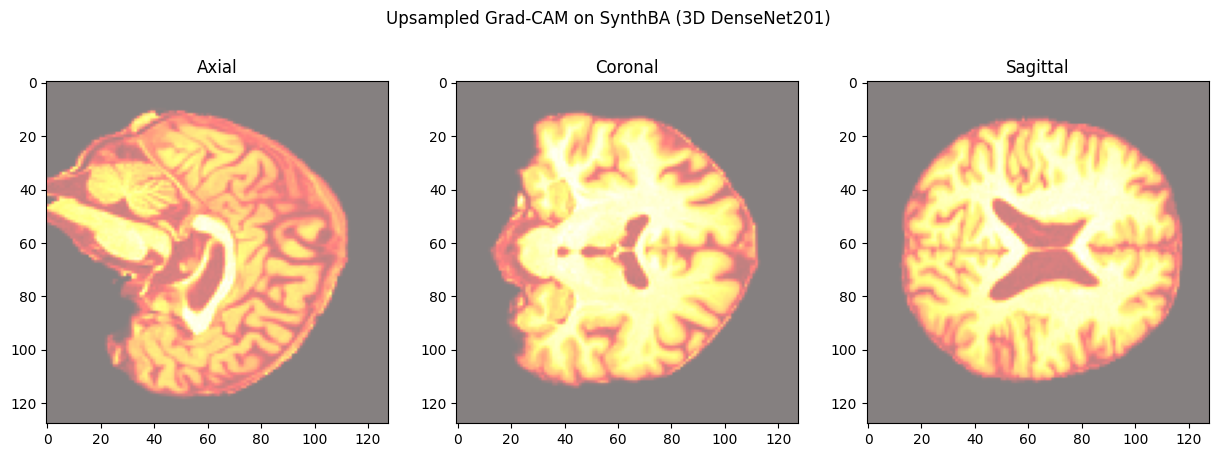

In [49]:
import matplotlib.pyplot as plt

# raw_img: already shape (D, H, W)
attr_map = ImageVolume.squeeze().detach().cpu().numpy()

# Get center slices
z, y, x = [s // 2 for s in attr_map.shape]

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(attr_map[z], cmap='hot', alpha=0.5)
plt.title("Axial")

plt.subplot(1,3,2)
plt.imshow(attr_map[:, y, :], cmap='hot', alpha=0.5)
plt.title("Coronal")

plt.subplot(1,3,3)
plt.imshow(attr_map[:, :, x], cmap='hot', alpha=0.5)
plt.title("Sagittal")

plt.suptitle("Upsampled Grad-CAM on SynthBA (3D DenseNet201)")
plt.show()

